# Sieci Neuronowe
## Ćwiczenie 2 - regresja logistyczna

Ważne: Zgodnie z ustaleniami na ostatnichm laboratorium, klasyfikujemy tylko chory / niechory. Jest to też narzucone przez metodę, ale warto o tym wspomnieć.

## 1. Import bibliotek

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

np.random.seed(42)

## 2. Implementacja funkcji pomocniczych

### Funkcja sigmoidalna

$\sigma(n) = \frac{1}{1 + e^{-n}}$

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

### Wizualizacja funkcji sigmoidalnej

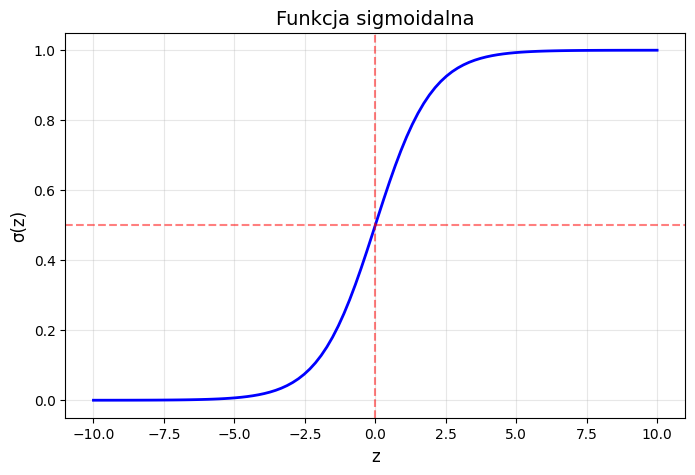

In [3]:
z = np.linspace(-10, 10, 100)
plt.figure(figsize=(8, 5))
plt.plot(z, sigmoid(z), 'b-', linewidth=2)
plt.grid(True, alpha=0.3)
plt.xlabel('z', fontsize=12)
plt.ylabel('σ(z)', fontsize=12)
plt.title('Funkcja sigmoidalna', fontsize=14)
plt.axhline(y=0.5, color='r', linestyle='--', alpha=0.5)
plt.axvline(x=0, color='r', linestyle='--', alpha=0.5)
plt.show()

## 3. Klasa regresji logistycznej

### Model

Wyjście modelu definiujemy jako:

$p(x) = \sigma(Wx + b)$

gdzie:
- $x$ - wektor wejściowy
- $W$ - macierz wag
- $b$ - bias

### Funkcja kosztu

Używamy enntropii krzyżowej:

$L = -y \ln p(x) - (1-y) \ln(1-p(x))$

### Gradient

Pochodna funkcji kosztu po wagach:

$\frac{\partial L}{\partial w} = -(y - p(x))x$

### Aktualizacja wag

$w' = w - \alpha \frac{\partial L}{\partial w}$

In [4]:
class LogisticRegression:
    def __init__(self, learning_rate=0.01, n_iterations=1000, verbose=False):
        self.learning_rate = learning_rate
        self.n_iterations = n_iterations
        self.verbose = verbose
        self.weights = None
        self.bias = None
        self.losses = []
    
    def _initialize_parameters(self, n_features):
        self.weights = np.zeros(n_features)
        self.bias = 0
    
    def _compute_loss(self, y_true, y_pred):
        """
        Took word for word from the lecture:
        L = -y*log(p(x)) - (1-y)*log(1-p(x))
        """
        epsilon = 1e-15  # no log 0
        y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
        loss = -np.mean(y_true * np.log(y_pred) + (1 - y_true) * np.log(1 - y_pred))
        return loss
    
    def fit(self, X, y):
        n_samples, n_features = X.shape
        self._initialize_parameters(n_features)
        
        # Gradient descent
        for i in range(self.n_iterations):
            linear_model = np.dot(X, self.weights) + self.bias
            y_pred = sigmoid(linear_model)
            
            dw = (1 / n_samples) * np.dot(X.T, (y_pred - y))
            db = (1 / n_samples) * np.sum(y_pred - y)
            
            # updating weights,
            self.weights -= self.learning_rate * dw
            self.bias -= self.learning_rate * db
            
            loss = self._compute_loss(y, y_pred)
            self.losses.append(loss)
            
            if self.verbose and (i % 100 == 0 or i == self.n_iterations - 1):
                print(f"Iteracja {i}: Loss = {loss:.4f}")
    
    def predict_proba(self, X):
        linear_model = np.dot(X, self.weights) + self.bias
        return sigmoid(linear_model)
    
    def predict(self, X, threshold=0.5):
        y_pred_proba = self.predict_proba(X)
        return (y_pred_proba >= threshold).astype(int)

## 4. Wczytanie i przygotowanie danych

Zbiór danych z poprzedniecgo laboratorium PO PRZYGOTOWANIU do użycia zgodnie z ostatnim raportem.

In [5]:
df = pd.read_csv('processed_heart_cleveland.csv')

print("Kształt danych:", df.shape)
print("\nPierwsze 5 wierszy:")
df.head()

Kształt danych: (303, 29)

Pierwsze 5 wierszy:


,target,age,trestbps,chol,thalach,oldpeak,sex_0.0,sex_1.0,cp_1.0,cp_2.0,...,slope_1.0,slope_2.0,slope_3.0,ca_0.0,ca_1.0,ca_2.0,ca_3.0,thal_3.0,thal_6.0,thal_7.0
0,0,0.948726,0.757525,-0.264900,0.017197,1.087338,False,True,True,False,...,False,False,True,True,False,False,False,False,True,False
1,1,1.392002,1.611220,0.760415,-1.821905,0.397182,False,True,False,False,...,False,True,False,False,False,False,True,True,False,False
2,1,1.392002,-0.665300,-0.342283,-0.902354,1.346147,False,True,False,False,...,False,True,False,False,False,True,False,False,False,True
3,0,-1.932564,-0.096170,0.063974,1.637359,2.122573,False,True,False,False,...,False,False,True,True,False,False,False,True,False,False
4,0,-1.489288,-0.096170,-0.825922,0.980537,0.310912,True,False,False,True,...,True,False,False,True,False,False,False,True,False,False


In [6]:
print("Informacje o zbiorze:")
print(df.info())
print("\nRozkład klas:")
print(df['target'].value_counts())

Informacje o zbiorze:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 303 entries, 0 to 302
Data columns (total 29 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   target       303 non-null    int64  
 1   age          303 non-null    float64
 2   trestbps     303 non-null    float64
 3   chol         303 non-null    float64
 4   thalach      303 non-null    float64
 5   oldpeak      303 non-null    float64
 6   sex_0.0      303 non-null    bool   
 7   sex_1.0      303 non-null    bool   
 8   cp_1.0       303 non-null    bool   
 9   cp_2.0       303 non-null    bool   
 10  cp_3.0       303 non-null    bool   
 11  cp_4.0       303 non-null    bool   
 12  fbs_0.0      303 non-null    bool   
 13  fbs_1.0      303 non-null    bool   
 14  restecg_0.0  303 non-null    bool   
 15  restecg_1.0  303 non-null    bool   
 16  restecg_2.0  303 non-null    bool   
 17  exang_0.0    303 non-null    bool   
 18  exang_1.0    303 non-null   

### Przygotowanie danych do uczenia
- Podział na zbiór uczący i testowy
- Standaryzację cech z użyciem biblioteki

In [7]:
X = df.drop('target', axis=1).values
y = df['target'].values

# (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print(f"Rozmiar zbioru uczącego: {X_train_scaled.shape}")
print(f"Rozmiar zbioru testowego: {X_test_scaled.shape}")
print(f"\nRozkład klas w zbiorze uczącym: {np.bincount(y_train)}")
print(f"Rozkład klas w zbiorze testowym: {np.bincount(y_test)}")

Rozmiar zbioru uczącego: (242, 28)
Rozmiar zbioru testowego: (61, 28)

Rozkład klas w zbiorze uczącym: [131 111]
Rozkład klas w zbiorze testowym: [33 28]


## 5. Uczenie modelu

In [8]:
model = LogisticRegression(learning_rate=0.1, n_iterations=1000, verbose=True)
model.fit(X_train_scaled, y_train)

Iteracja 0: Loss = 0.6931
Iteracja 100: Loss = 0.3364
Iteracja 200: Loss = 0.3298
Iteracja 300: Loss = 0.3281
Iteracja 400: Loss = 0.3275
Iteracja 500: Loss = 0.3272
Iteracja 600: Loss = 0.3271
Iteracja 700: Loss = 0.3270
Iteracja 800: Loss = 0.3270
Iteracja 900: Loss = 0.3270
Iteracja 999: Loss = 0.3270


### Wizualizacja procesu uczenia

wartość funkcji kosztu zmieniająca się w kolejnych iteracjach.

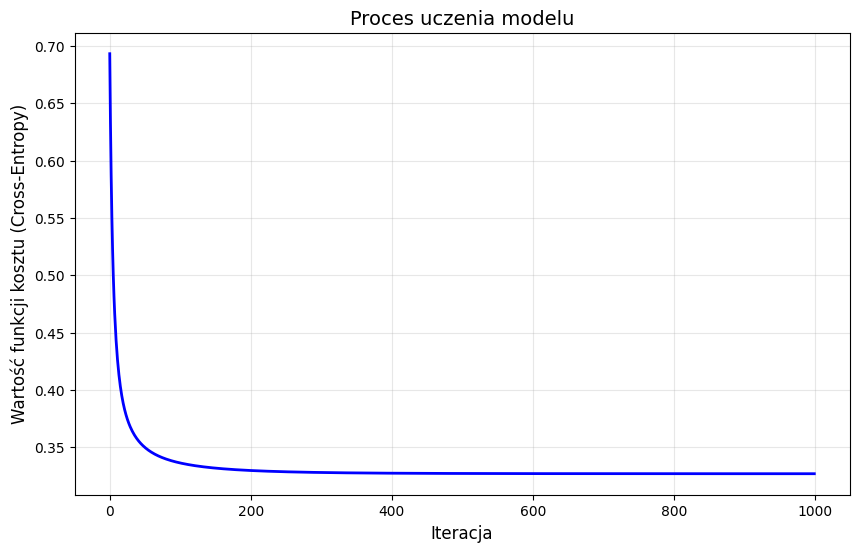

Początkowy koszt: 0.6931
Końcowy koszt: 0.3270
Redukcja kosztu: 52.82%


In [9]:
plt.figure(figsize=(10, 6))
plt.plot(model.losses, 'b-', linewidth=2)
plt.xlabel('Iteracja', fontsize=12)
plt.ylabel('Wartość funkcji kosztu (Cross-Entropy)', fontsize=12)
plt.title('Proces uczenia modelu', fontsize=14)
plt.grid(True, alpha=0.3)
plt.show()

print(f"Początkowy koszt: {model.losses[0]:.4f}")
print(f"Końcowy koszt: {model.losses[-1]:.4f}")
print(f"Redukcja kosztu: {(1 - model.losses[-1]/model.losses[0])*100:.2f}%")

## 6. Ewaluacja modelu

Sprawdzamy model na zbiorze testowym.

In [10]:
y_pred_train = model.predict(X_train_scaled)
y_pred_test = model.predict(X_test_scaled)

train_accuracy = accuracy_score(y_train, y_pred_train)
test_accuracy = accuracy_score(y_test, y_pred_test)

print(f"Dokładność na zbiorze uczącym: {train_accuracy:.4f} ({train_accuracy*100:.2f}%)")
print(f"Dokładność na zbiorze testowym: {test_accuracy:.4f} ({test_accuracy*100:.2f}%)")

Dokładność na zbiorze uczącym: 0.8802 (88.02%)
Dokładność na zbiorze testowym: 0.8525 (85.25%)


### Macierz pomyłek

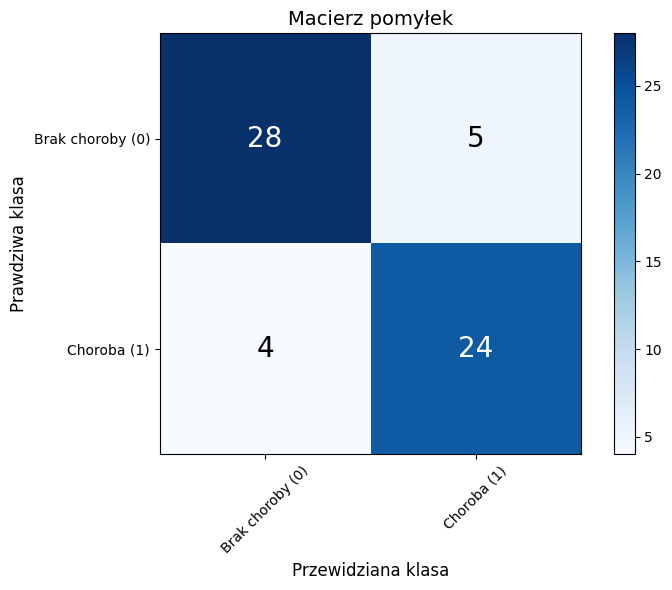


Macierz pomyłek:
[[28  5]
 [ 4 24]]


In [11]:
cm = confusion_matrix(y_test, y_pred_test)

plt.figure(figsize=(8, 6))
plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.title('Macierz pomyłek', fontsize=14)
plt.colorbar()

classes = ['Brak choroby (0)', 'Choroba (1)']
tick_marks = np.arange(len(classes))
plt.xticks(tick_marks, classes, rotation=45)
plt.yticks(tick_marks, classes)

thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                ha="center", va="center",
                color="white" if cm[i, j] > thresh else "black",
                fontsize=20)

plt.ylabel('Prawdziwa klasa', fontsize=12)
plt.xlabel('Przewidziana klasa', fontsize=12)
plt.tight_layout()
plt.show()

print("\nMacierz pomyłek:")
print(cm)

### Szczegółowy raport klasyfikacji

In [12]:
print("Rapor:")
print(classification_report(y_test, y_pred_test, target_names=['Brak choroby', 'Choroba']))

Rapor:
              precision    recall  f1-score   support

Brak choroby       0.88      0.85      0.86        33
     Choroba       0.83      0.86      0.84        28

    accuracy                           0.85        61
   macro avg       0.85      0.85      0.85        61
weighted avg       0.85      0.85      0.85        61



## 7. Analiza wag modelu

Zbadamy które cechy mają największy wpływ na predykcję.

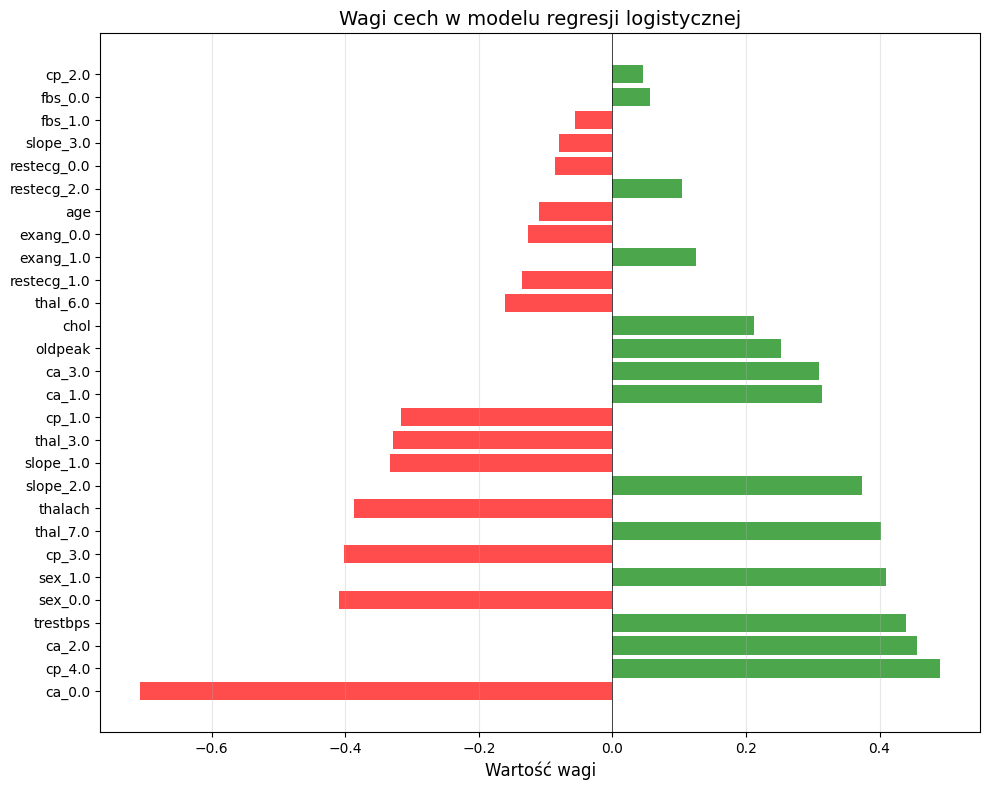


Wagi posortowane według wartości bezwzględnej:
          Cecha      Waga
21       ca_0.0 -0.706910
10       cp_4.0  0.490540
23       ca_2.0  0.455717
1      trestbps  0.440298
5       sex_0.0 -0.409737
6       sex_1.0  0.409737
9        cp_3.0 -0.401888
27     thal_7.0  0.401828
3       thalach -0.387043
19    slope_2.0  0.374124
18    slope_1.0 -0.333180
25     thal_3.0 -0.328036
7        cp_1.0 -0.316145
22       ca_1.0  0.313192
24       ca_3.0  0.308688
4       oldpeak  0.252624
2          chol  0.211860
26     thal_6.0 -0.160675
14  restecg_1.0 -0.136069
17    exang_1.0  0.125705
16    exang_0.0 -0.125705
0           age -0.110096
15  restecg_2.0  0.104162
13  restecg_0.0 -0.086684
20    slope_3.0 -0.079843
12      fbs_1.0 -0.055761
11      fbs_0.0  0.055761
8        cp_2.0  0.045287

Bias: -0.1141


In [13]:
feature_names = df.drop('target', axis=1).columns
weights_df = pd.DataFrame({
    'Cecha': feature_names,
    'Waga': model.weights
}).sort_values('Waga', key=abs, ascending=False)

plt.figure(figsize=(10, 8))
colors = ['red' if w < 0 else 'green' for w in weights_df['Waga']]
plt.barh(range(len(weights_df)), weights_df['Waga'], color=colors, alpha=0.7)
plt.yticks(range(len(weights_df)), weights_df['Cecha'])
plt.xlabel('Wartość wagi', fontsize=12)
plt.title('Wagi cech w modelu regresji logistycznej', fontsize=14)
plt.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.show()

print("\nWagi posortowane według wartości bezwzględnej:")
print(weights_df)
print(f"\nBias: {model.bias:.4f}")

## 8. Eksperyment z różnymi hiperparametrami

Jak różne wartości współczynnika uczenia wpływają na proces uczenia.

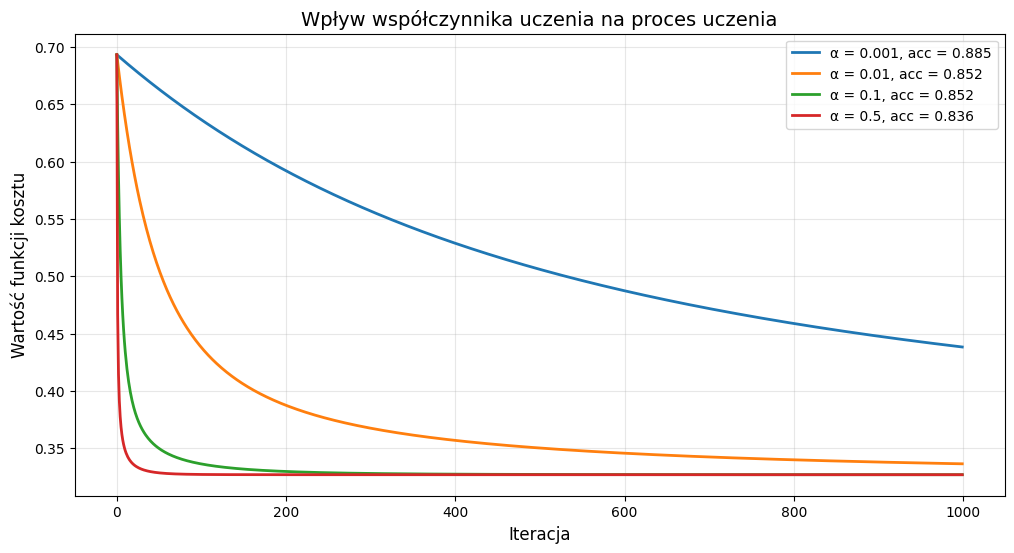


Dokładność dla różnych współczynników uczenia:
α = 0.001: 0.8852 (88.52%)
α = 0.01: 0.8525 (85.25%)
α = 0.1: 0.8525 (85.25%)
α = 0.5: 0.8361 (83.61%)


In [14]:
learning_rates = [0.001, 0.01, 0.1, 0.5]
results = {}

plt.figure(figsize=(12, 6))

for lr in learning_rates:
    model_temp = LogisticRegression(learning_rate=lr, n_iterations=1000, verbose=False)
    model_temp.fit(X_train_scaled, y_train)
    
    y_pred = model_temp.predict(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    results[lr] = acc
    
    plt.plot(model_temp.losses, label=f'α = {lr}, acc = {acc:.3f}', linewidth=2)

plt.xlabel('Iteracja', fontsize=12)
plt.ylabel('Wartość funkcji kosztu', fontsize=12)
plt.title('Wpływ współczynnika uczenia na proces uczenia', fontsize=14)
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

print("\nDokładność dla różnych współczynników uczenia:")
for lr, acc in results.items():
    print(f"α = {lr}: {acc:.4f} ({acc*100:.2f}%)")

## 9. Krzywa ROC i AUC

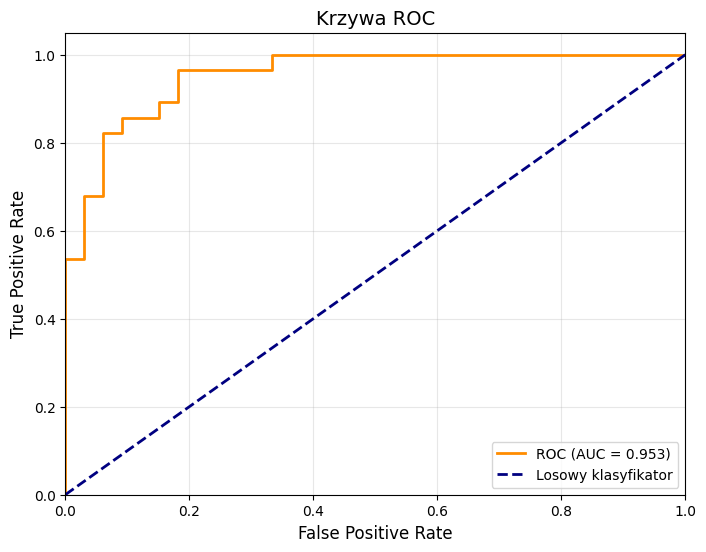

AUC (Area Under Curve): 0.9535


In [15]:
from sklearn.metrics import roc_curve, auc

y_pred_proba = model.predict_proba(X_test_scaled)

fpr, tpr, thresholds = roc_curve(y_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'ROC (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Losowy klasyfikator')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('Krzywa ROC', fontsize=14)
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.show()

print(f"AUC (Area Under Curve): {roc_auc:.4f}")

## 10. Wnioski

- Model regresji logistycznej jako najprostsza forma sieci neuronowej skutecznie klasyfikuje przypadki chorób serca z ok. 85% dokładnością. Natomiast, jest to wynik, który mógłby posłużyć do bardzo wstępnego screeningu pacjentów, którzy dalej musieliby udać się do lekarza.

- Funkcja sigmoidalna przekształca liniową kombinację cech na prawdopodobieństwa w przedziale [0,1], jest to bardzo wygodne do uycia. (Przemyślenie: może dzięki niej nie były potem potrzebny softmax w konkretnych przypadkach (?))

- Entropia krzyżowa jako funkcja kosztu pozwala na efektywną optymalizację parametrów modelu w tym pzrypadku

- Gradient descent z odpowiednio dobranym współczynnikiem uczenia doprowadził do zbieżości modelu

- Współczynnik uczenia (α) ma kluczowy wpływ na proces uczenia:
  - Zbyt małe wartości powodują wolną zbieżność
  - Zbyt duże wartości mogą prowadzić do niestabilności
  - Wartość około 0.1 daje dobre rezultaty dla tego problemu

- Standaryzacja cech jest istotna dla efektywnego uczenia modelu

- Model osiąga porównywalną dokładność na zbiorach uczącym i testowym => sugeruje brak overfittingu

### Zalety

- Prostota implementacji i interpretacji regresji logistycznej
- Szybkie uczenie
- Probabilistyczna interpretacja wyników
- Możliwość analizy wpływu poszczególnych cech

### Ograniczenia

- Zakłada liniową separowalność klas (duży problem!)
- Ograniczona do klasyfikacji binarnej (w znanej mi formie)